In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

df = pd.read_csv('high_risk_pregnancy_realistic_2000 (1).csv')

In [ ]:
import joblib

x_train_smote = joblib.load('x_train_smote.pkl')
y_train_smote = joblib.load('y_train_smote.pkl')
x_test_scaled = joblib.load('x_test_scaled.pkl')
y_test        = joblib.load('y_test.pkl')

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    random_state=20,
    is_unbalance=True
)

In [11]:
lgbm_model.fit(x_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 1366, number of negative: 1366
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002668 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3132
[LightGBM] [Info] Number of data points in the train set: 2732, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(is_unbalance=True, random_state=20)

In [12]:
lgbm_pred = lgbm_model.predict(x_test_scaled)

In [13]:
lgbm_prob = lgbm_model.predict_proba(x_test_scaled)[:, 1]
print(lgbm_prob)

[0.08925451 0.00728775 0.02085452 0.15288965 0.72682274 0.09538276
 0.07796332 0.11145119 0.60509494 0.03119474 0.56068368 0.44928231
 0.17168069 0.02596609 0.22910721 0.05395297 0.0135809  0.73364573
 0.01196114 0.03235475 0.10704086 0.23618099 0.53953033 0.01660698
 0.56403557 0.07713325 0.02448419 0.01375491 0.27953222 0.02067488
 0.43940781 0.36925382 0.01323146 0.29465395 0.37164315 0.00702156
 0.00179518 0.00273788 0.22492034 0.1742482  0.47741545 0.00766225
 0.02142369 0.81507203 0.07167164 0.02823918 0.12145178 0.09135125
 0.01471612 0.01571866 0.01937611 0.00717436 0.00734493 0.83791234
 0.10237106 0.21533453 0.2721799  0.35834072 0.13870156 0.02461655
 0.02377927 0.01991178 0.02343383 0.40981325 0.02725674 0.15602266
 0.14079615 0.57465011 0.12756789 0.03208668 0.02949965 0.67504235
 0.01573385 0.05189727 0.16241789 0.01757705 0.02054837 0.30323092
 0.14022997 0.10439169 0.1198242  0.03592765 0.00742499 0.02209853
 0.1612601  0.24999314 0.06448329 0.01144296 0.29969092 0.0291

In [14]:
lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
print("LightGBM Accuracy:", round(lgbm_accuracy, 4))

LightGBM Accuracy: 0.7995


In [15]:
print("Classification Report\n")
print(classification_report(y_test, lgbm_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       330
           1       0.37      0.23      0.29        69

    accuracy                           0.80       399
   macro avg       0.61      0.58      0.58       399
weighted avg       0.77      0.80      0.78       399



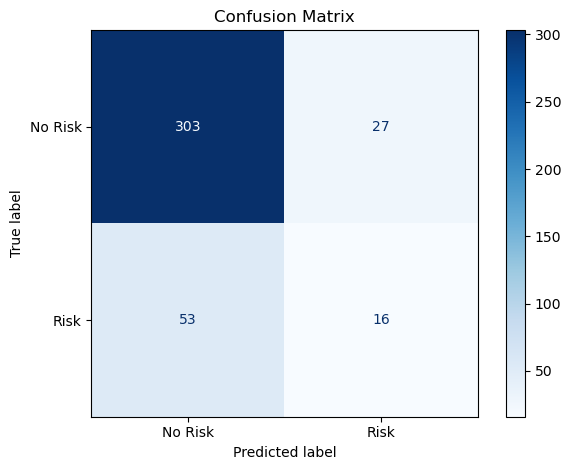

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, lgbm_pred, display_labels=['No Risk', 'Risk'], cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

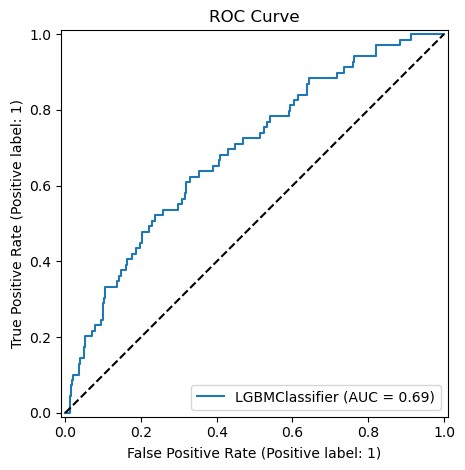

In [17]:
RocCurveDisplay.from_estimator(lgbm_model, x_test_scaled, y_test)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.tight_layout()
plt.show()

In [18]:
print('ROC-AUC Score:', roc_auc_score(y_test, lgbm_prob).round(4))

ROC-AUC Score: 0.6871


In [19]:
precision = precision_score(y_test, lgbm_pred)
recall    = recall_score(y_test, lgbm_pred)
f1        = f1_score(y_test, lgbm_pred)

print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Precision: 0.3721
Recall   : 0.2319
F1 Score : 0.2857


In [20]:
X = df.drop('risk_class', axis=1)
feature_names = X.columns
n_importances = len(lgbm_model.feature_importances_)

print("df shape:", df.shape)
print("x_train_smote shape:", x_train_smote.shape)

df shape: (2000, 24)
x_train_smote shape: (2732, 28)


In [21]:
if len(feature_names) == n_importances:
    labels = feature_names
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance = pd.DataFrame({
    "Feature":    labels,
    "Importance": lgbm_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance.to_string(index=False))

   Feature  Importance
 feature_9         266
feature_13         245
 feature_7         210
feature_11         194
feature_10         192
feature_12         179
 feature_6         176
feature_14         173
 feature_8         171
feature_18         164
feature_15         140
 feature_0         133
feature_16         107
feature_24          68
feature_19          65
feature_21          61
 feature_1          60
feature_25          58
feature_17          56
feature_22          55
feature_23          48
feature_27          45
feature_26          44
feature_20          34
 feature_4          25
 feature_3          16
 feature_2          15
 feature_5           0


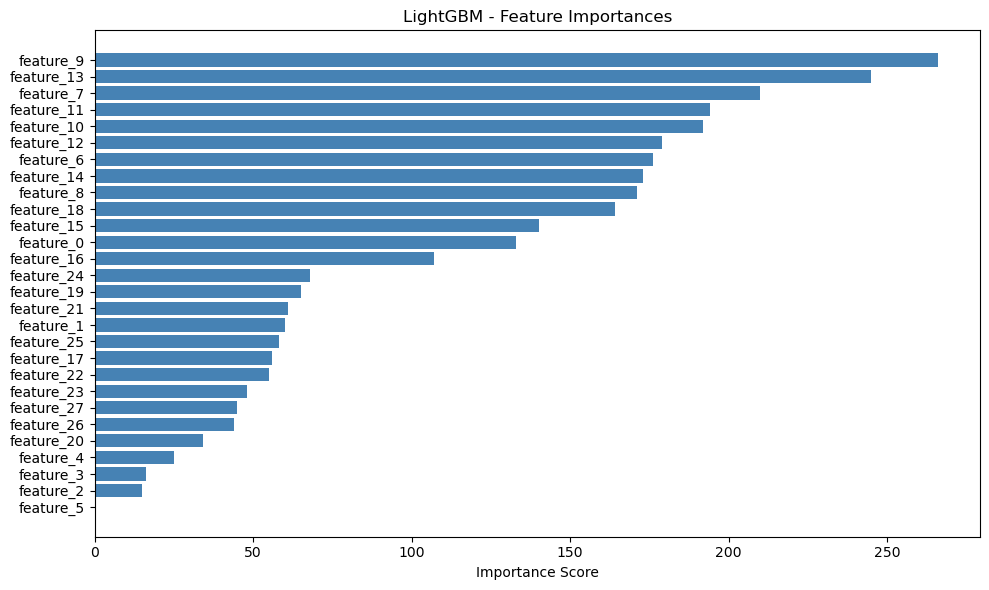

In [22]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("LightGBM - Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
train_pred = lgbm_model.predict(x_train_smote)
print("Train Accuracy:", round(accuracy_score(y_train_smote, train_pred), 4))
print("Test Accuracy :", round(lgbm_accuracy, 4))

Train Accuracy: 1.0
Test Accuracy : 0.7995


In [24]:
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    LGBMClassifier(random_state=20, is_unbalance=True),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(x_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 1366, number of negative: 1366
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3132
[LightGBM] [Info] Number of data points in the train set: 2732, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

GridSearchCV(cv=5, estimator=LGBMClassifier(is_unbalance=True, random_state=20),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [25]:
print("Best Params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}


In [26]:
best_pred = best_model.predict(x_test_scaled)
best_prob = best_model.predict_proba(x_test_scaled)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test, best_pred), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test, best_prob).round(4))

Best Model Accuracy: 0.807
Best Model ROC-AUC : 0.6715


In [27]:
cv_scores = cross_val_score(lgbm_model, x_train_smote, y_train_smote, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores.round(4))
print("Mean:", cv_scores.mean().round(4), "| Std dev:", cv_scores.std().round(4))

[LightGBM] [Info] Number of positive: 1092, number of negative: 1093
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3128
[LightGBM] [Info] Number of data points in the train set: 2185, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499771 -> initscore=-0.000915
[LightGBM] [Info] Start training from score -0.000915
[LightGBM] [Info] Number of positive: 1093, number of negative: 1092
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3132
[LightGBM] [Info] Number of data points in the train set: 2185, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500229 -> initscore=0.000915
[LightGBM

In [28]:
joblib.dump(lgbm_model, 'lgbm_model.pkl')
print("Model saved.")

Model saved.
